Research figure saved as figure_rows_spaced.png


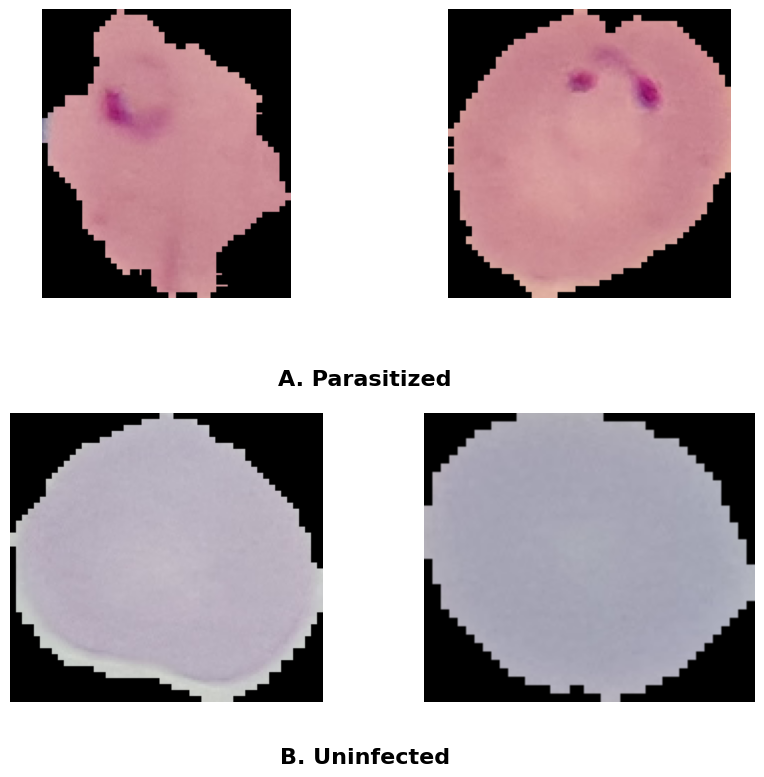

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import random

def generate_row_grouped_grid_with_space(base_path, output_filename='figure_rows_spaced.png'):
    # Create a 2x2 figure: 2 rows (one for each category), 2 columns (for samples)
    # hspace adds the space between the rows
    fig, axes = plt.subplots(2, 2, figsize=(10, 9), gridspec_kw={'hspace': 0.4})
    
    # Define groups: (Label, Folder Name, Row Index)
    groups = [('A. Parasitized', 'Parasitized', 0), ('B. Uninfected', 'Uninfected', 1)]
    
    for label, folder_name, row_idx in groups:
        folder_path = os.path.join(base_path, folder_name)
        img_names = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg'))][:2]
        
        for col_idx, img_name in enumerate(img_names):
            img = cv2.imread(os.path.join(folder_path, img_name))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis('off')
        
        # Place label at the bottom-center of the row pair
        # We target the center of the row, adjusted for the spacing
        fig.text(0.5, 0.48 - (row_idx * 0.42), label, 
                 ha='center', va='top', fontsize=16, fontweight='bold')

    # Save the figure with tight layout, keeping our extra space
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Research figure saved as {output_filename}")
    plt.show()

# --- Execution ---
base_path = '/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images'
generate_row_grouped_grid_with_space(base_path)

In [2]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.transforms import RandomErasing
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score
from tqdm import tqdm
import warnings
import random
import re
from collections import defaultdict
import time
import matplotlib.pyplot as plt
import torch.nn.functional as F
from skimage.segmentation import mark_boundaries

# ---------- SHAP and LIME imports ----------
import shap
from lime import lime_image

warnings.filterwarnings('ignore')

# -------------------- Deterministic Seed --------------------
def set_deterministic(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

# -------------------- MixUp Augmentation --------------------
class MixUp:
    def __init__(self, alpha=0.2):
        self.alpha = alpha

    def __call__(self, batch):
        images, labels = zip(*batch)
        images = torch.stack(images, 0)
        labels = torch.tensor(labels)
        if self.alpha > 0:
            lam = np.random.beta(self.alpha, self.alpha)
        else:
            lam = 1.0
        batch_size = images.size(0)
        index = torch.randperm(batch_size)
        mixed_images = lam * images + (1 - lam) * images[index, :]
        labels_a, labels_b = labels, labels[index]
        return mixed_images, labels_a, labels_b, lam

# -------------------- Dataset for Training (with transforms) --------------------
class OriginalDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, target_size=(256,256)):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        if img is None:
            img = np.zeros((*self.target_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_AREA)
        img = Image.fromarray(img)
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------- Dataset for TTA (returns PIL images, no transforms) --------------------
class PILDataset(Dataset):
    def __init__(self, image_paths, labels, target_size=(256,256)):
        self.image_paths = image_paths
        self.labels = labels
        self.target_size = target_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        if img is None:
            img = np.zeros((*self.target_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_AREA)
        img = Image.fromarray(img)
        label = self.labels[idx]
        return img, label

# -------------------- Custom collate function for PIL images --------------------
def pil_collate(batch):
    images, labels = zip(*batch)
    return list(images), torch.tensor(labels)

# ===================== SIMPLE EVALUATION (NO TTA) =====================
def evaluate_simple(model, loader, criterion, device):
    model.eval()
    all_preds, all_targets = [], []
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
    acc = accuracy_score(all_targets, all_preds)
    avg_val_loss = val_loss / len(loader.dataset)
    return acc, avg_val_loss, all_preds, all_targets

# -------------------- Training Function (Enhanced) --------------------
def train_model(train_loader, test_loader, model_name="ResNet18_Enhanced", epochs=15, patience=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nTraining {model_name} on {device}...")

    model = models.resnet18(pretrained=True)
    for param in model.parameters():
        param.requires_grad = True
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, 2)
    )
    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0
    mixup = MixUp(alpha=0.2)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch in tqdm(train_loader, desc=f"{model_name} Epoch {epoch}/{epochs}"):
            images, labels = batch
            mixed_images, labels_a, labels_b, lam = mixup(list(zip(images, labels)))
            mixed_images = mixed_images.to(device)
            labels_a = labels_a.to(device)
            labels_b = labels_b.to(device)
            lam = torch.tensor(lam, dtype=torch.float).to(device)

            optimizer.zero_grad()
            outputs = model(mixed_images)
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * mixed_images.size(0)

        # Validation
        val_acc, val_loss, _, _ = evaluate_simple(model, test_loader, criterion, device)
        print(f"Epoch {epoch}: Train Loss: {running_loss/len(train_loader.dataset):.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
                break

    model.load_state_dict(best_model_state)
    final_acc, _, preds, targets = evaluate_simple(model, test_loader, criterion, device)
    return model, final_acc, preds, targets

# -------------------- Evaluation Function with TTA --------------------
def evaluate_model_with_tta(model, pil_loader, device, model_name="Model"):
    model.eval()
    all_targets = []
    all_preds = []
    all_probs = []
    inference_times = []

    tta_transforms = [
        transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
        transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
        transforms.Compose([
            transforms.RandomVerticalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
        transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.RandomVerticalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
        transforms.Compose([
            transforms.RandomRotation(degrees=15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    ]

    with torch.no_grad():
        for images, targets in tqdm(pil_loader, desc=f"Evaluating {model_name} with TTA"):
            targets = targets.to(device)
            all_targets.extend(targets.cpu().numpy())

            if device.type == 'cuda':
                torch.cuda.synchronize()
                start = time.time()
                tta_batch = []
                for tta_tf in tta_transforms:
                    aug_images = torch.stack([tta_tf(img) for img in images])
                    tta_batch.append(aug_images)
                tta_images = torch.cat(tta_batch, dim=0).to(device)
                outputs = model(tta_images)
                torch.cuda.synchronize()
                elapsed = (time.time() - start) * 1000 / len(images)
            else:
                start = time.time()
                tta_batch = []
                for tta_tf in tta_transforms:
                    aug_images = torch.stack([tta_tf(img) for img in images])
                    tta_batch.append(aug_images)
                tta_images = torch.cat(tta_batch, dim=0).to(device)
                outputs = model(tta_images)
                elapsed = (time.time() - start) * 1000 / len(images)
            inference_times.append(elapsed)

            num_aug = len(tta_transforms)
            batch_size = len(images)
            outputs = outputs.view(num_aug, batch_size, -1)
            probs = torch.softmax(outputs, dim=2)
            avg_probs = probs.mean(dim=0)
            _, preds = torch.max(avg_probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(avg_probs.cpu().numpy())

    targets_np = np.array(all_targets)
    preds_np = np.array(all_preds)
    probs_np = np.array(all_probs)

    accuracy = accuracy_score(targets_np, preds_np)
    precision, recall, f1, _ = precision_recall_fscore_support(targets_np, preds_np, average=None)
    macro_prec, macro_rec, macro_f1 = precision_recall_fscore_support(targets_np, preds_np, average='macro')[:3]
    weighted_prec, weighted_rec, weighted_f1 = precision_recall_fscore_support(targets_np, preds_np, average='weighted')[:3]
    pos_prec = precision[1] if len(precision) > 1 else None
    pos_rec = recall[1]
    pos_f1 = f1[1]

    auc = roc_auc_score(targets_np, probs_np[:, 1]) if probs_np.shape[1] == 2 else roc_auc_score(targets_np, probs_np, multi_class='ovr')
    cm = confusion_matrix(targets_np, preds_np)

    total_params = sum(p.numel() for p in model.parameters())
    model_size_mb = total_params * 4 / (1024 * 1024)
    avg_inference_ms = np.mean(inference_times)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'macro_precision': macro_prec,
        'macro_recall': macro_rec,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_prec,
        'weighted_recall': weighted_rec,
        'weighted_f1': weighted_f1,
        'pos_precision': pos_prec,
        'pos_recall': pos_rec,
        'pos_f1': pos_f1,
        'auc': auc,
        'confusion_matrix': cm,
        'total_params': total_params,
        'model_size_mb': model_size_mb,
        'inference_ms': avg_inference_ms,
        'predictions': preds_np,
        'targets': targets_np,
        'probabilities': probs_np
    }

# ===================== GRAD-CAM IMPLEMENTATION =====================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        # Find and register hooks
        found = False
        for name, module in model.named_modules():
            if name == target_layer:
                module.register_forward_hook(forward_hook)
                module.register_backward_hook(backward_hook)
                found = True
                break
        if not found:
            raise ValueError(f"Layer '{target_layer}' not found in the model.")
    
    def generate_cam(self, input_image, target_class=None):
        self.model.eval()
        output = self.model(input_image)
        if target_class is None:
            target_class = torch.argmax(output, dim=1).item()
        
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)
        
        gradients = self.gradients          # (1, C, H', W')
        activations = self.activations      # (1, C, H', W')
        
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam = torch.sum(weights * activations, dim=1, keepdim=True) # (1,1,H',W')
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = F.interpolate(cam, size=input_image.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return cam, target_class

def visualize_gradcam(model, image_tensor, label, device, target_layer='layer4', save_path=None):
    """
    image_tensor: tensor of shape (1, 3, H, W) preprocessed, on device
    label: true label (int)
    """
    grad_cam = GradCAM(model, target_layer)
    heatmap, pred_class = grad_cam.generate_cam(image_tensor)
    
    # Undo normalization and convert to numpy (H,W,3) in [0,1]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)
    img = image_tensor * std + mean
    img = img.squeeze().cpu().permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)
    
    # Resize heatmap to original image size
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * img + 0.5 * heatmap_colored
    overlay = np.clip(overlay, 0, 1)
    
    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(f'Grad-CAM: true={label}, pred={pred_class}')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    return heatmap

def explain_with_shap(model, train_loader, test_images, test_labels, device, 
                      num_background=100, vmax=None, class_idx=None):
    """
    Generate SHAP explanations with improved visibility for faint gradients.

    Parameters:
    -----------
    vmax : float, optional
        Max absolute value for colormap. If None, auto-set to max_abs * 0.5.
    class_idx : int, optional
        Which class SHAP values to plot. If None, uses the true class (test_labels).
    """
    num_images = min(5, len(test_images))
    if num_images == 0:
        print("No test images.")
        return

    # ---- Sample background ----
    background = []
    with torch.no_grad():
        for images, _ in train_loader:
            background.append(images[:num_background // len(train_loader) + 1])
            if sum(b.shape[0] for b in background) >= num_background:
                break
    background = torch.cat(background, dim=0)[:num_background].to(device)

    # ---- Move to CPU ----
    model_cpu = model.to('cpu')
    model_cpu.eval()
    test_images_cpu = test_images[:num_images].to('cpu')
    background_cpu = background.to('cpu')

    # ---- SHAP with GradientExplainer ----
    explainer = shap.GradientExplainer(model_cpu, background_cpu)
    shap_values = explainer.shap_values(test_images_cpu)  # list of (N, C, H, W)

    actual_samples = shap_values[0].shape[0]
    if actual_samples < num_images:
        print(f"Warning: SHAP returned {actual_samples} samples, using that.")
        test_images_cpu = test_images_cpu[:actual_samples]
        test_labels = test_labels[:actual_samples]
        num_images = actual_samples

    # ---- Choose which class to plot ----
    # If class_idx not given, use the true label for each image
    if class_idx is None:
        # For multi-class, we need to index shap_values with the true class per sample
        # shap_values is a list of arrays (one per class), each (N, H, W, C) after transpose
        # We'll pick the corresponding class for each image and stack them
        shap_values_per_class = []
        for i in range(num_images):
            true_label = test_labels[i].item()
            # shap_values[true_label] is (N, H, W, C) – take the i-th sample
            shap_values_per_class.append(shap_values[true_label][i][None, ...])
        shap_values_plot = np.concatenate(shap_values_per_class, axis=0)  # (N, H, W, C)
    else:
        # Use a fixed class index
        shap_values_plot = shap_values[class_idx].transpose(0, 2, 3, 1)

    # If you have binary classification (2 classes), you might want to plot
    # the positive class (class 1) – adjust accordingly.

    # ---- Denormalize images ----
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    images_denorm = test_images_cpu * std + mean
    images_denorm = torch.clamp(images_denorm, 0, 1)
    images_np = images_denorm.numpy().transpose(0, 2, 3, 1)   # (N, H, W, 3)

    # ---- Determine vmax automatically if not provided ----
    max_abs = np.max(np.abs(shap_values_plot))
    print(f"Max absolute SHAP value: {max_abs:.6f}")
    if vmax is None:
        vmax = max_abs * 0.5 if max_abs > 0 else 1e-6
        print(f"Auto-setting vmax = {vmax:.6f} (you can override with a smaller value)")

    # ---- Plot with the (possibly auto) vmax ----
    shap.image_plot([shap_values_plot], images_np, show=False, vmax=vmax)

    # ---- Set titles ----
    fig = plt.gcf()
    # With a single class, there are 2 columns: original + overlay
    axes = fig.axes
    for i in range(num_images):
        ax = axes[i * 2]   # first column is the original image
        ax.set_title(f"True: {test_labels[i].item()}")
    plt.show()

    # ---- Restore model ----
    model.to(device)
    
# ===================== LIME EXPLAINER =====================
def explain_with_lime(model, pil_loader, device, num_samples=100):
    """
    model: trained PyTorch model
    pil_loader: DataLoader returning PIL images and labels
    """
    model_cpu = model.to('cpu')
    model_cpu.eval()
    
    # Predictor function for LIME
    def predict(images):
        # images: list of numpy arrays (H,W,3) in [0,1]
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        batch = torch.stack([transform(img) for img in images])
        with torch.no_grad():
            out = model_cpu(batch)
        probs = torch.softmax(out, dim=1).numpy()
        return probs
    
    # Get a batch of test images
    images, labels = next(iter(pil_loader))
    explainer = lime_image.LimeImageExplainer()
    
    for idx in range(min(5, len(images))):
        explanation = explainer.explain_instance(
            np.array(images[idx]),
            predict,
            top_labels=2,
            hide_color=0,
            num_samples=num_samples
        )
        # Show the explanation for the top predicted class
        temp, mask = explanation.get_image_and_mask(
            explanation.top_labels[0],
            positive_only=True,
            num_features=10,
            hide_rest=False
        )
        plt.figure(figsize=(6,6))
        plt.imshow(mark_boundaries(temp, mask))
        plt.axis('off')
        plt.title(f"LIME for test image {idx} (true label: {labels[idx].item()})")
        plt.show()

# ==========================================================
# MAIN
# ==========================================================

In [3]:
set_deterministic(42)

base_path = '/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images'
categories = ['Uninfected', 'Parasitized']

# Build paths and labels
image_paths, labels = [], []
for cat_idx, cat in enumerate(categories):
    folder = os.path.join(base_path, cat)
    exts = ('.png', '.jpg', '.jpeg')
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(exts)]
    image_paths.extend(files)
    labels.extend([cat_idx] * len(files))

# Patient-aware split
path_to_label = {path: label for path, label in zip(image_paths, labels)}
patient_to_images = defaultdict(list)
for path in image_paths:
    match = re.search(r'P(\d+)', os.path.basename(path))
    patient_id = f"P{match.group(1)}" if match else os.path.basename(path).split('_')[0]
    patient_to_images[patient_id].append(path)

unique_patients = list(patient_to_images.keys())
patient_majority_label = {}
for pid, paths in patient_to_images.items():
    lbls = [path_to_label[p] for p in paths]
    patient_majority_label[pid] = max(set(lbls), key=lbls.count)

patient_labels = [patient_majority_label[pid] for pid in unique_patients]

train_patients, test_patients = train_test_split(
    unique_patients, test_size=0.20, random_state=42, stratify=patient_labels
)

train_paths, train_labels = [], []
test_paths, test_labels = [], []
for pid in train_patients:
    for p in patient_to_images[pid]:
        train_paths.append(p); train_labels.append(path_to_label[p])
for pid in test_patients:
    for p in patient_to_images[pid]:
        test_paths.append(p); test_labels.append(path_to_label[p])

# Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    RandomErasing(p=0.2, scale=(0.02, 0.1))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

target_size = (256, 256)

train_dataset = OriginalDataset(train_paths, train_labels, transform=train_transform, target_size=target_size)
test_dataset  = OriginalDataset(test_paths, test_labels, transform=test_transform, target_size=target_size)
pil_test_dataset = PILDataset(test_paths, test_labels, target_size=target_size)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size, shuffle=False, num_workers=4, pin_memory=True)
pil_test_loader = DataLoader(pil_test_dataset, batch_size, shuffle=False, num_workers=4, collate_fn=pil_collate)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ========== 1. Train Enhanced Model ==========
model, best_acc, _, _ = train_model(
    train_loader, test_loader, model_name="ResNet18_Enhanced", epochs=15, patience=5
)

# ========== 2. Evaluate Enhanced Model with TTA ==========
print("\n" + "="*60)
print("EVALUATING ENHANCED MODEL WITH TTA")
print("="*60)
metrics = evaluate_model_with_tta(model, pil_test_loader, device, model_name="Enhanced_ResNet18")
print(f"Test Accuracy (TTA): {metrics['accuracy']*100:.2f}%")
print(f"Precision (Parasitized): {metrics['pos_precision']:.3f}")
print(f"Recall (Parasitized): {metrics['pos_recall']:.3f}")
print(f"F1 (Parasitized): {metrics['pos_f1']:.3f}")
print(f"AUC: {metrics['auc']:.3f}")
print("\nConfusion Matrix:\n", metrics['confusion_matrix'])
print("\nClassification Report:")
print(classification_report(metrics['targets'], metrics['predictions'],
                            target_names=['Uninfected', 'Parasitized']))



Training ResNet18_Enhanced on cuda...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 152MB/s]
ResNet18_Enhanced Epoch 1/15: 100%|██████████| 349/349 [02:33<00:00,  2.27it/s]


Epoch 1: Train Loss: 0.4082 | Val Loss: 0.2687 | Val Acc: 96.43%


ResNet18_Enhanced Epoch 2/15: 100%|██████████| 349/349 [02:35<00:00,  2.25it/s]


Epoch 2: Train Loss: 0.3696 | Val Loss: 0.2737 | Val Acc: 96.62%


...

Epoch 14: Train Loss: 0.3339 | Val Loss: 0.2600 | Val Acc: 97.77%


ResNet18_Enhanced Epoch 15/15: 100%|██████████| 349/349 [02:34<00:00,  2.25it/s]


Epoch 15: Train Loss: 0.3301 | Val Loss: 0.2476 | Val Acc: 97.63%

EVALUATING ENHANCED MODEL WITH TTA


Evaluating Enhanced_ResNet18 with TTA: 100%|██████████| 82/82 [01:11<00:00,  1.14it/s]

Test Accuracy (TTA): 97.67%
Precision (Parasitized): 0.980
Recall (Parasitized): 0.972
F1 (Parasitized): 0.976
AUC: 0.996

Confusion Matrix:
 [[2675   51]
 [  71 2440]]

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.97      0.98      0.98      2726
 Parasitized       0.98      0.97      0.98      2511

    accuracy                           0.98      5237
   macro avg       0.98      0.98      0.98      5237
weighted avg       0.98      0.98      0.98      5237



In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.segmentation import mark_boundaries


def get_selected_samples(test_loader, pil_test_loader, device, num_parasitized=2, num_uninfected=1):
    selected = []
    needed = {1: num_parasitized, 0: num_uninfected}
    collected = {0: 0, 1: 0}
    
    for (tensor_batch, labels), (pil_batch, _) in zip(test_loader, pil_test_loader):
        for idx, label in enumerate(labels):
            lbl = label.item()
            if collected[lbl] < needed[lbl]:
                img_tensor = tensor_batch[idx:idx+1].to(device)
                pil_img = pil_batch[idx]
                selected.append({
                    'image_tensor': img_tensor,
                    'pil_image': pil_img,
                    'label': lbl,
                })
                collected[lbl] += 1
                # FIX: remove all() and check conditions directly
                if collected[0] >= needed[0] and collected[1] >= needed[1]:
                    return selected
    return selected
    
def denormalize(tensor):
    """Convert normalized tensor (1,3,H,W) to numpy (H,W,3) in [0,1]."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(tensor.device)
    img = tensor * std + mean
    img = img.squeeze().cpu().permute(1,2,0).numpy()
    return np.clip(img, 0, 1)

def get_shap_overlay(model, img_tensor, true_label, device, train_loader, num_background=100):
    """Return SHAP overlay image (H,W,3) as numpy array in [0,1]."""
    model_cpu = model.to('cpu')
    model_cpu.eval()
    img_cpu = img_tensor.to('cpu')

    # Sample background
    background = []
    with torch.no_grad():
        for images, _ in train_loader:
            background.append(images[:num_background // len(train_loader) + 1])
            if sum(b.shape[0] for b in background) >= num_background:
                break
    background = torch.cat(background, dim=0)[:num_background].to('cpu')

    explainer = shap.GradientExplainer(model_cpu, background)
    shap_values = explainer.shap_values(img_cpu)   # list of arrays per class (or single array)

    # Determine the structure
    if len(shap_values) == 1:
        # Single array containing values for all classes
        shap_arr = shap_values[0]  # shape: (1, C, H, W) or (1, H, W, C)
        # Remove batch dimension
        shap_arr = shap_arr[0]     # now (C, H, W) or (H, W, C)
        # Check if first dimension is number of classes (2)
        if shap_arr.shape[0] == 2:  # channels first
            shap_val = shap_arr[true_label]  # (H, W)
            # Need to add channel dim for blending? We'll handle later
            # Actually shap_val is 2D (H,W); we'll make it 3D by repeating
            shap_val = np.expand_dims(shap_val, axis=2)  # (H, W, 1)
        else:
            # Assume shape (H, W, C) with C=number of classes
            shap_val = shap_arr[:, :, true_label]  # (H, W)
            shap_val = np.expand_dims(shap_val, axis=2)  # (H, W, 1)
    else:
        # Expected: list with one array per class
        shap_val = shap_values[true_label][0]  # (H, W, C) or (C, H, W)
        # Ensure (H, W, C)
        if shap_val.ndim == 3 and shap_val.shape[0] == 3:
            shap_val = shap_val.transpose(1, 2, 0)

    # Now shap_val should be (H, W, C) with C=3 (RGB) or C=1 (grayscale heatmap)
    # If it's (H, W, 1), we need to convert to 3-channel heatmap
    if shap_val.shape[2] == 1:
        # Use absolute values and create heatmap
        abs_shap = np.abs(shap_val[:, :, 0])  # (H, W)
        abs_shap = abs_shap / (abs_shap.max() + 1e-8)
        import matplotlib.cm as cm
        heatmap = cm.jet(abs_shap)[:, :, :3]  # (H, W, 3)
    else:
        # Multiple channels: average absolute values across channels
        abs_shap = np.abs(shap_val).mean(axis=2)  # (H, W)
        abs_shap = abs_shap / (abs_shap.max() + 1e-8)
        heatmap = cm.jet(abs_shap)[:, :, :3]

    # Denormalize original image
    img_np = denormalize(img_tensor)  # (H, W, 3)

    overlay = 0.5 * img_np + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    model.to(device)
    return overlay

def get_lime_overlay(model, pil_image, device, num_samples=100):
    """Return LIME overlay image (H,W,3) as numpy array."""
    model_cpu = model.to('cpu')
    model_cpu.eval()
    
    def predict(images):
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        batch = torch.stack([transform(img) for img in images])
        with torch.no_grad():
            out = model_cpu(batch)
        return torch.softmax(out, dim=1).numpy()
    
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        np.array(pil_image),
        predict,
        top_labels=2,
        hide_color=0,
        num_samples=num_samples
    )
    # Get the top predicted class mask
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )
    # temp is the image with highlighted regions (numpy)
    # We want the overlay image (the one with boundaries)
    overlay = mark_boundaries(temp / 255.0, mask)  # temp is uint8, scale to [0,1]
    
    model.to(device)
    return overlay

def get_gradcam_overlay(model, img_tensor, true_label, device, target_layer='layer4'):
    """Return Grad-CAM overlay image (H,W,3) as numpy array."""
    grad_cam = GradCAM(model, target_layer)
    heatmap, pred_class = grad_cam.generate_cam(img_tensor)
    # Denormalize image
    img_np = denormalize(img_tensor)
    # Resize heatmap
    heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * img_np + 0.5 * heatmap_colored
    return np.clip(overlay, 0, 1)

def plot_explanations_row(model, train_loader, test_loader, pil_test_loader, device):
    """
    Main function: selects samples, computes all explanations, and plots them in a row.
    """
    # 1. Select samples
    samples = get_selected_samples(test_loader, pil_test_loader, device,
                                   num_parasitized=2, num_uninfected=1)
    if len(samples) < 3:
        print("Not enough samples found.")
        return
    
    # 2. For each sample, compute overlays
    rows = []
    titles = []
    for s in samples:
        img_tensor = s['image_tensor']
        pil_img = s['pil_image']
        label = s['label']
        label_name = 'Parasitized' if label == 1 else 'Uninfected'
        
        # Original image (denormalized)
        orig = denormalize(img_tensor)
        
        # SHAP
        shap_overlay = get_shap_overlay(model, img_tensor, label, device, train_loader)
        
        # LIME
        lime_overlay = get_lime_overlay(model, pil_img, device)
        
        # Grad-CAM
        gradcam_overlay = get_gradcam_overlay(model, img_tensor, label, device)
        
        rows.append([orig, shap_overlay, lime_overlay, gradcam_overlay])
        titles.append(label_name)
    
    # 3. Plot 3 rows x 4 columns
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
    col_titles = ['Original', 'SHAP', 'LIME', 'Grad-CAM']
    
    for i in range(3):
        for j in range(4):
            ax = axes[i, j]
            ax.imshow(rows[i][j])
            ax.axis('off')
            if i == 0:
                ax.set_title(col_titles[j])
            if j == 0:
                ax.set_ylabel(titles[i], fontsize=12, rotation=90, labelpad=20)
    
    plt.tight_layout()
    plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

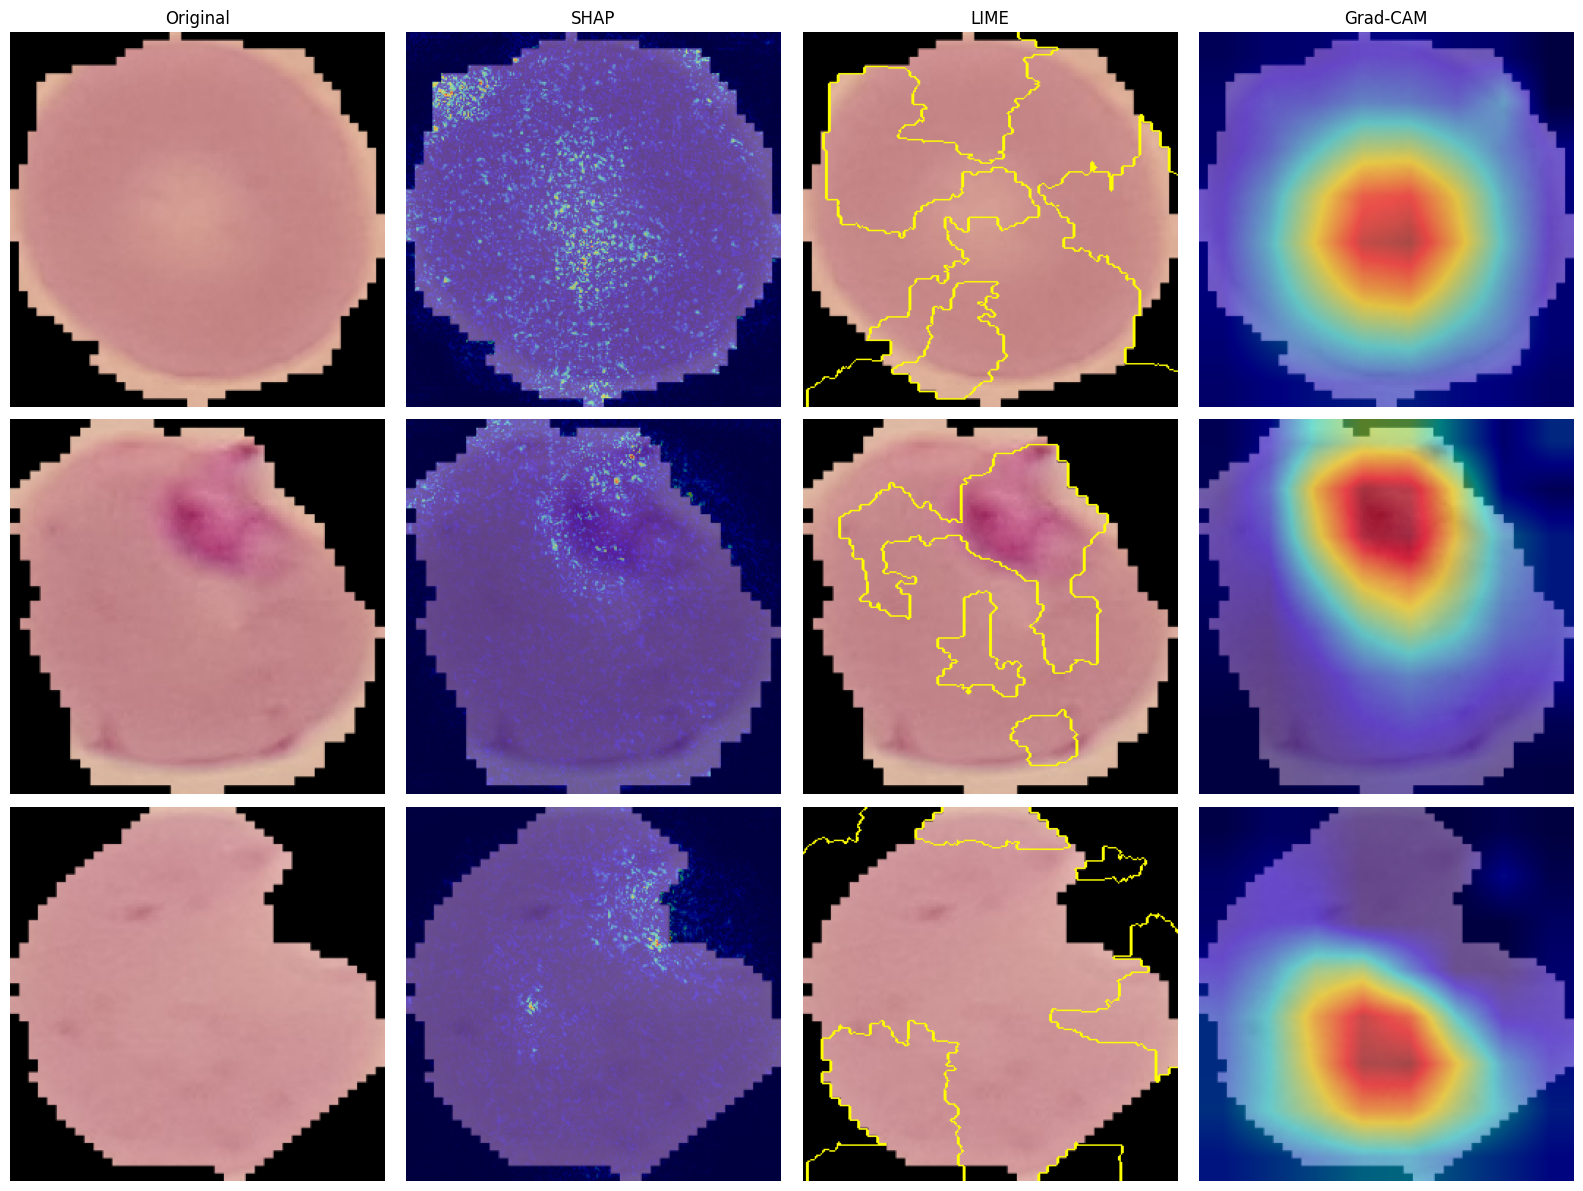

In [5]:
plot_explanations_row(model, train_loader, test_loader, pil_test_loader, device)